# Entraînement supervisé

Ce notebook permet d'effectuer un entraînement supervisé du réseau de neurones du joueur DL

In [ ]:
import sys
sys.path.append('../onitama/')
from trainer import RegularDataTrainer
from dl_players_v7 import DensePlayer_v7
import numpy as np
from livelossplot import PlotLossesKeras
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import glob
import os


2026-03-24 11:21:25.425721: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-24 11:21:25.449424: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-24 11:21:26.404870: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-24 11:21:28.316174: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computat

In [ ]:
#Configuration
folder_data = "../data/"
dst_folder = "../models/training/"
dst_model_name = "tairanauchu-training-supervise"

In [ ]:
#Boite à outils de fonctions

#Convertit une action ou un batch d'actions [col, ligne, action_id] en one-hot
def action_to_one_hot(action, shape=(5, 5, 52)):
    if isinstance(action, list) and len(action) == 3:
        # Une seule action
        col, ligne, action_id = action
        one_hot = np.zeros(shape, dtype=np.float32)
        one_hot[col, ligne, action_id] = 1.0
        return one_hot
    else:
        # Batch d'actions
        batch_size = len(action)
        one_hot_batch = np.zeros((batch_size, *shape), dtype=np.float32)
        
        for i, act in enumerate(action):
            col, ligne, action_id = act
            one_hot_batch[i, col, ligne, action_id] = 1.0
        
        return one_hot_batch

#Décode un un vecteur (1300,) en action [col, ligne, move_id]
def decode_flat_policy(flat_policy):
    #Trouver l'index du maximum (ou du 1.0 si one-hot)
    best_index = np.argmax(flat_policy)
    
    #Décoder l'index
    col = best_index // (5 * 52)
    ligne = (best_index // 52) % 5
    move_id = best_index % 52
    
    return [int(col), int(ligne), int(move_id)]


## Chargement et préparation des données

In [ ]:
#Récupération des données

# Scanner le dossier et grouper par préfixe (nom de base sans suffixe)
states_files = sorted(glob.glob(os.path.join(folder_data, "*.states.pkl")))
basenames = [os.path.basename(f).replace(".states.pkl", "") for f in states_files]

policy_files = [os.path.join(folder_data, f"{b}.labels.pkl") for b in basenames]
mask_files   = [os.path.join(folder_data, f"{b}.mask.pkl")   for b in basenames]

# Vérifier que tous les fichiers existent
for s, p, m in zip(states_files, policy_files, mask_files):
    for path in [s, p, m]:
        if not os.path.exists(path):
            print(f"Fichier manquant : {path}")

print(f"{len(basenames)} jeu(x) de données trouvé(s) :")
for b in basenames:
    print(f"  - {b}")

states = []
policies = []
masks = []

for s_file, p_file, m_file in zip(states_files, policy_files, mask_files):
    states   += RegularDataTrainer.getTrainedData(filepath=s_file)
    policies += RegularDataTrainer.getTrainedData(filepath=p_file)
    masks    += RegularDataTrainer.getTrainedData(filepath=m_file)
    print(f"Chargé : {os.path.basename(s_file)}")

print("\n\nTotal :")
print(f"{len(states)} states")
print(f"{len(policies)} policies")
print(f"{len(masks)} masks")
print(f"{len(policies) / 18} jeux (approx.)")

# Filtrer les entrées dont le state n'a pas la shape attendue (10, 5, 5)
EXPECTED_SHAPE = (10, 5, 5)
valid = [np.array(s).shape == EXPECTED_SHAPE for s in states]
n_invalid = sum(1 for v in valid if not v)
if n_invalid > 0:
    print(f"{n_invalid} états ignorés (shape incorrecte)")
    states   = [s for s, v in zip(states,   valid) if v]
    policies = [p for p, v in zip(policies, valid) if v]
    masks    = [m for m, v in zip(masks,    valid) if v]

states = np.array(states)
print(states.shape)

states = np.transpose(states, (0, 2, 3, 1))
print(states.shape) #Maintenant on est bien (en 5,5,10)

6 jeu(x) de données trouvé(s) :
  - LookAheadHeuristic3heuristic_aggressive-vs-LookAheadHeuristic2heuristic_defensive
  - LookAheadHeuristic3heuristic_aggressive-vs-LookAheadHeuristic2heuristic_regular
  - LookAheadHeuristic3heuristic_defensive-vs-LookAheadHeuristic2heuristic_aggressive
  - LookAheadHeuristic3heuristic_defensive-vs-LookAheadHeuristic2heuristic_mobility
  - LookAheadHeuristic3heuristic_defensive-vs-LookAheadHeuristic2heuristic_positional
  - LookAheadHeuristic3heuristic_defensive-vs-LookAheadHeuristic2heuristic_regular
Chargé : LookAheadHeuristic3heuristic_aggressive-vs-LookAheadHeuristic2heuristic_defensive.states.pkl
Chargé : LookAheadHeuristic3heuristic_aggressive-vs-LookAheadHeuristic2heuristic_regular.states.pkl
Chargé : LookAheadHeuristic3heuristic_defensive-vs-LookAheadHeuristic2heuristic_aggressive.states.pkl
Chargé : LookAheadHeuristic3heuristic_defensive-vs-LookAheadHeuristic2heuristic_mobility.states.pkl
Chargé : LookAheadHeuristic3heuristic_defensive-vs-Look

In [ ]:

#On applique one Hot Encoder sur les actions (policies)
policies = action_to_one_hot(policies)


In [ ]:

#Aplatir pour correspondre à la sortie du modèle
policies = policies.reshape(-1, 5 * 5 * 52)  # (batch, 1300)


In [ ]:
#Concatner avec les masques (que les actions valides)
masks = np.array(masks, dtype=np.float32)
y_masked = np.concatenate([policies, masks], axis=1)

In [ ]:
# Mélange
indices = np.random.permutation(len(states))
states    = states[indices]
y_masked  = y_masked[indices]
print(f"Données mélangées : {len(states)} échantillons")

Données mélangées : 474458 échantillons


In [9]:
policies[0]

array([0., 0., 0., ..., 0., 0., 0.], shape=(1300,), dtype=float32)

## Chargement du modèle

In [10]:
network = DensePlayer_v7(dropout_rate=0.2)


2026-03-24 11:22:12.383286: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


In [11]:
# Compiler pour supervised (gèle value head - spécifier d'utiliser les masques pour le calcul de la loss)
network.compile_for_supervised_policy(use_mask=True)

Gelé 4 layers de la tête de valeur
Modèle compilé pour entraînement supervisé (policy seulement, label_smoothing=0.0, weight_decay=0.0001, use_mask=True)


In [12]:
network.summary()

Model: "OnitamaNetwork-v7-Dense"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ state_input         │ (None, 5, 5, 10)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ trunk_flatten       │ (None, 250)       │          0 │ state_input[0][0] │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ trunk_dense_0       │ (None, 512)       │    128,512 │ trunk_flatten[0]… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ trunk_bn_0          │ (None, 512)       │      2,048 │ trunk_dense_0[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ trunk_relu_0        │ (None, 512)       │          0 │ trunk_bn_0[0][0]  │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ trunk_dropout_0     │ (None, 512)       │          0 │ trunk_relu_0[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ trunk_dense_1       │ (None, 512)       │    262,656 │ trunk_dropout_0[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ trunk_bn_1          │ (None, 512)       │      2,048 │ trunk_dense_1[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ trunk_relu_1        │ (None, 512)       │          0 │ trunk_bn_1[0][0]  │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ trunk_dropout_1     │ (None, 512)       │          0 │ trunk_relu_1[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ trunk_dense_2       │ (None, 256)       │    131,328 │ trunk_dropout_1[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ trunk_bn_2          │ (None, 256)       │      1,024 │ trunk_dense_2[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ trunk_relu_2        │ (None, 256)       │          0 │ trunk_bn_2[0][0]  │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ trunk_dropout_2     │ (None, 256)       │          0 │ trunk_relu_2[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ value_dense1        │ (None, 128)       │     32,896 │ trunk_dropout_2[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ value_dropout       │ (None, 128)       │          0 │ value_dense1[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ policy_dropout      │ (None, 256)       │          0 │ trunk_dropout_2[

 Total params: 902,933 (3.44 MB)

 Trainable params: 859,156 (3.28 MB)

 Non-trainable params: 43,777 (171.00 KB)

## Entraînement

In [13]:
x_train  = states
y_value  = np.zeros((len(x_train), 1))

In [14]:
y_policy = y_masked[:, :1300]  # conserver séparément pour les évaluations top-k

In [ ]:

early_stop = EarlyStopping(
    monitor='val_policy_logits_accuracy',
    patience=5,
    restore_best_weights=True,
    mode='max'
)

checkpoint = ModelCheckpoint(
    filepath=f"{dst_folder}{dst_model_name}.weights.h5",
    monitor='val_policy_logits_accuracy',
    save_best_only=True,
    save_weights_only=True,
    mode='max',
    verbose=1
)

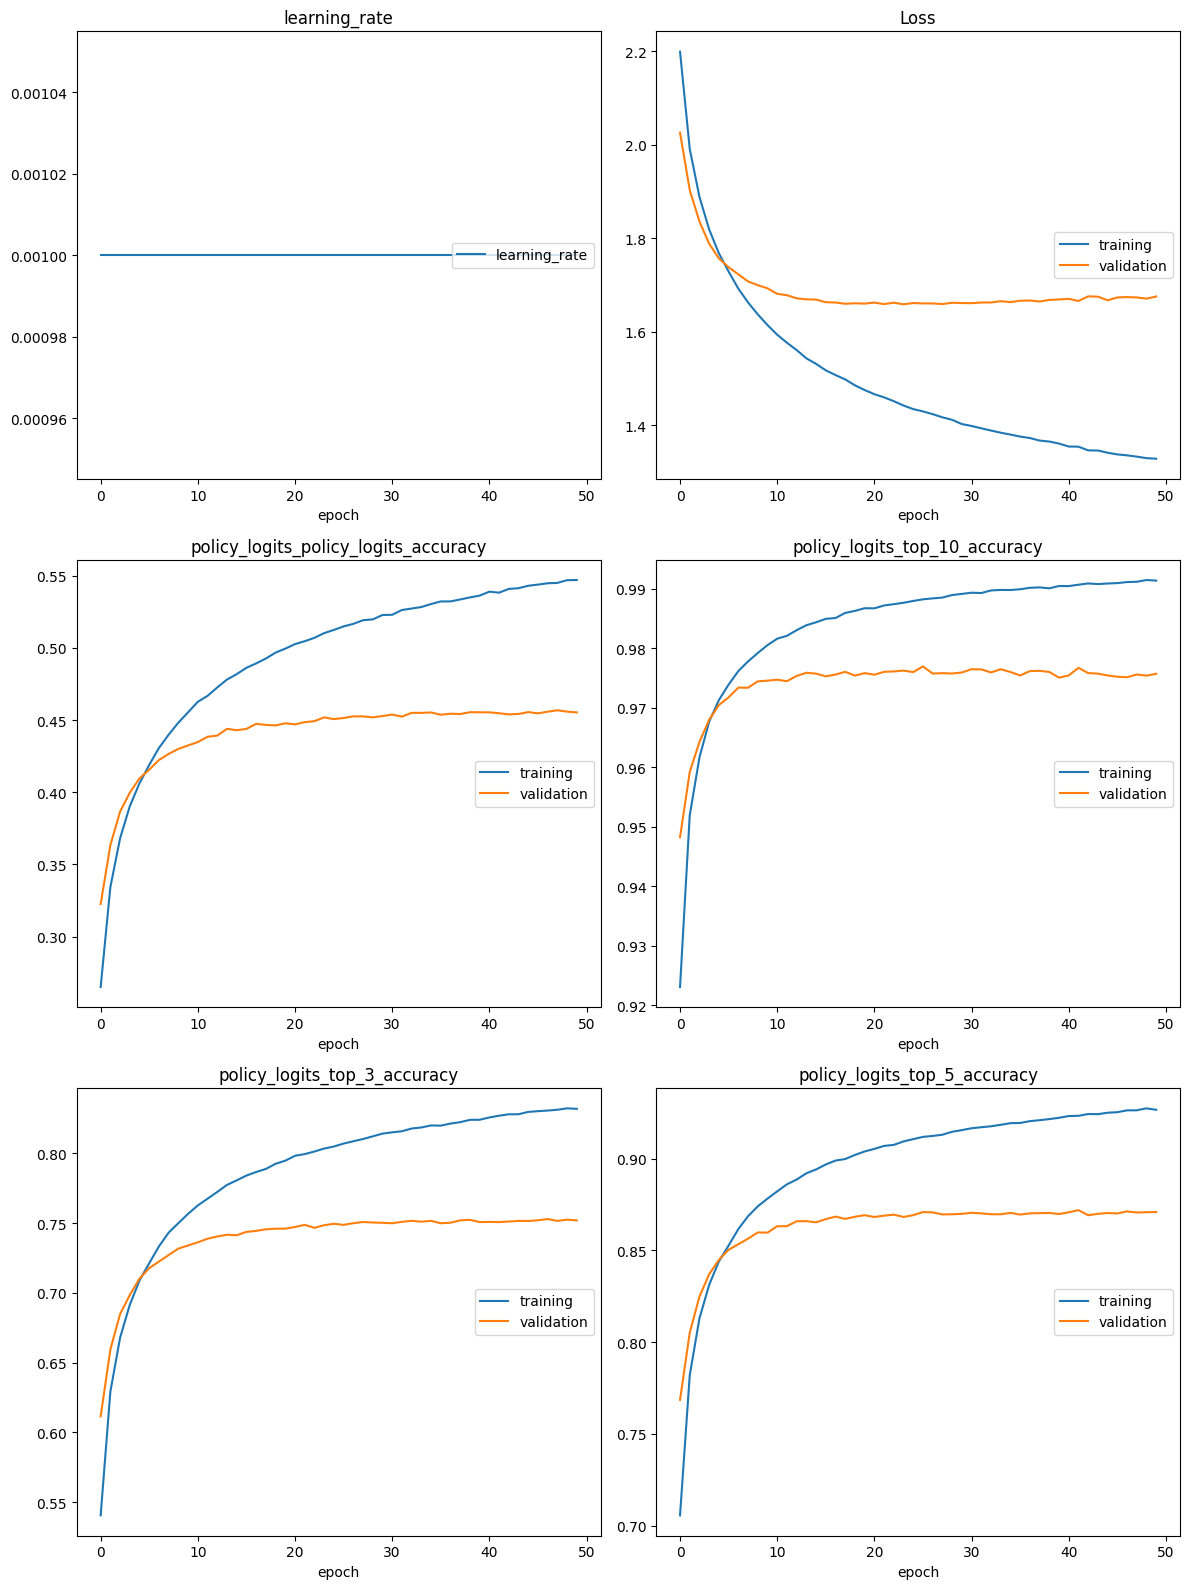

learning_rate
	learning_rate    	 (min:    0.001, max:    0.001, cur:    0.001)
Loss
	training         	 (min:    1.329, max:    2.199, cur:    1.329)
	validation       	 (min:    1.659, max:    2.026, cur:    1.675)
policy_logits_policy_logits_accuracy
	training         	 (min:    0.265, max:    0.547, cur:    0.547)
	validation       	 (min:    0.323, max:    0.457, cur:    0.455)
policy_logits_top_10_accuracy
	training         	 (min:    0.923, max:    0.992, cur:    0.991)
	validation       	 (min:    0.948, max:    0.977, cur:    0.976)
policy_logits_top_3_accuracy
	training         	 (min:    0.541, max:    0.832, cur:    0.832)
	validation       	 (min:    0.611, max:    0.753, cur:    0.752)
policy_logits_top_5_accuracy
	training         	 (min:    0.706, max:    0.927, cur:    0.927)
	validation       	 (min:    0.769, max:    0.872, cur:    0.871)
5931/5931 ━━━━━━━━━━━━━━━━━━━━ 82s 12ms/step - loss: 1.3286 - policy_logits_policy_logits_accuracy: 0.5470 - policy_logits_top_10_

In [ ]:

# Entraîner
history = network.fit(
    x_train,
    [y_masked, y_value],  # y_value sera ignoré - ici on utilise y_masked au lieu de y_policy
    batch_size=64,
    validation_batch_size=512,
    shuffle=True,
    epochs=50,
    validation_split=0.2,
    callbacks=[early_stop, checkpoint, PlotLossesKeras()]
)